# Sentiment Analysis for AMZN (Amazon.com Inc.)

This notebook performs sentiment analysis specifically on AMZN-related news headlines.

## Focus:
- Amazon stock sentiment analysis
- E-commerce sector sentiment
- Cloud computing and retail sentiment indicators

## Tools:
- TextBlob for primary sentiment analysis
- NLTK VADER for comparison

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK VADER data (only needed once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load AMZN-specific data
print("Loading AMZN data...")

# Load raw analyst ratings data
raw_data = pd.read_csv('../../../data/newsData/raw_analyst_ratings.csv')
print(f"Total dataset shape: {raw_data.shape}")

# Filter for AMZN only
amzn_data = raw_data[raw_data['stock'] == 'AMZN'].copy()
print(f"AMZN headlines: {len(amzn_data)}")

# Load aligned data
aligned_data = pd.read_csv('../../../data/aligned_data/news_mapped_to_trading_days.csv')
amzn_aligned = aligned_data[aligned_data['stock'] == 'AMZN'].copy()
print(f"AMZN aligned data: {len(amzn_aligned)}")

# Display sample AMZN headlines
print("\nSample AMZN headlines:")
for i, headline in enumerate(amzn_data['headline'].head(5).tolist()):
    print(f"{i+1}. {headline}")

Loading AMZN data...
Total dataset shape: (1407328, 6)
AMZN headlines: 278
AMZN aligned data: 278

Sample AMZN headlines:
1. How Cannabis Company Cannaphyll Is Marketing On Mass-Consumer Platforms, Google And Amazon
2. Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
3. Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BAC, NIO, SONO, GLW
4. Hearing Vertical Group Out Positive On Amazon, Saying Co.'s Ad Spend Revenues Are Increasing As Shipping Bottleneck Issues Begin To Abate
5. Big Tech Reaches New Record Heights At The Stock Market


In [3]:
# Initialize sentiment analyzers
def get_textblob_sentiment(text):
    """Get sentiment scores using TextBlob"""
    try:
        blob = TextBlob(str(text))
        return {
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }
    except:
        return {'polarity': 0.0, 'subjectivity': 0.0}

vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get sentiment scores using NLTK VADER"""
    try:
        scores = vader.polarity_scores(str(text))
        return {
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral': scores['neu']
        }
    except:
        return {'compound': 0.0, 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

print("Sentiment analyzers initialized!")

Sentiment analyzers initialized!


In [4]:
# Apply sentiment analysis to AMZN data
print("Applying sentiment analysis to AMZN headlines...")

# Apply TextBlob sentiment analysis
print("Calculating TextBlob sentiment scores...")
amzn_data['textblob_polarity'] = amzn_data['headline'].apply(lambda x: get_textblob_sentiment(x)['polarity'])
amzn_data['textblob_subjectivity'] = amzn_data['headline'].apply(lambda x: get_textblob_sentiment(x)['subjectivity'])

# Apply VADER sentiment analysis
print("Calculating VADER sentiment scores...")
amzn_data['vader_compound'] = amzn_data['headline'].apply(lambda x: get_vader_sentiment(x)['compound'])
amzn_data['vader_positive'] = amzn_data['headline'].apply(lambda x: get_vader_sentiment(x)['positive'])
amzn_data['vader_negative'] = amzn_data['headline'].apply(lambda x: get_vader_sentiment(x)['negative'])

print("Sentiment analysis completed!")
print(f"Processed {len(amzn_data)} AMZN headlines")

Applying sentiment analysis to AMZN headlines...
Calculating TextBlob sentiment scores...
Calculating VADER sentiment scores...
Sentiment analysis completed!
Processed 278 AMZN headlines


In [5]:
# AMZN Sentiment Analysis Summary
print("=== AMZN SENTIMENT ANALYSIS SUMMARY ===")

# TextBlob statistics
print("\nTextBlob Polarity Statistics:")
print(f"Mean: {amzn_data['textblob_polarity'].mean():.4f}")
print(f"Std: {amzn_data['textblob_polarity'].std():.4f}")
print(f"Min: {amzn_data['textblob_polarity'].min():.4f}")
print(f"Max: {amzn_data['textblob_polarity'].max():.4f}")
print(f"Median: {amzn_data['textblob_polarity'].median():.4f}")

print("\nTextBlob Subjectivity Statistics:")
print(f"Mean: {amzn_data['textblob_subjectivity'].mean():.4f}")
print(f"Std: {amzn_data['textblob_subjectivity'].std():.4f}")

# VADER statistics
print("\nVADER Compound Statistics:")
print(f"Mean: {amzn_data['vader_compound'].mean():.4f}")
print(f"Std: {amzn_data['vader_compound'].std():.4f}")
print(f"Min: {amzn_data['vader_compound'].min():.4f}")
print(f"Max: {amzn_data['vader_compound'].max():.4f}")
print(f"Median: {amzn_data['vader_compound'].median():.4f}")

# Correlation
correlation = amzn_data['textblob_polarity'].corr(amzn_data['vader_compound'])
print(f"\nCorrelation between TextBlob and VADER: {correlation:.4f}")

=== AMZN SENTIMENT ANALYSIS SUMMARY ===

TextBlob Polarity Statistics:
Mean: 0.0403
Std: 0.1861
Min: -0.6250
Max: 0.8000
Median: 0.0000

TextBlob Subjectivity Statistics:
Mean: 0.2038
Std: 0.2567

VADER Compound Statistics:
Mean: 0.1097
Std: 0.3076
Min: -0.8689
Max: 0.8807
Median: 0.0000

Correlation between TextBlob and VADER: 0.2155


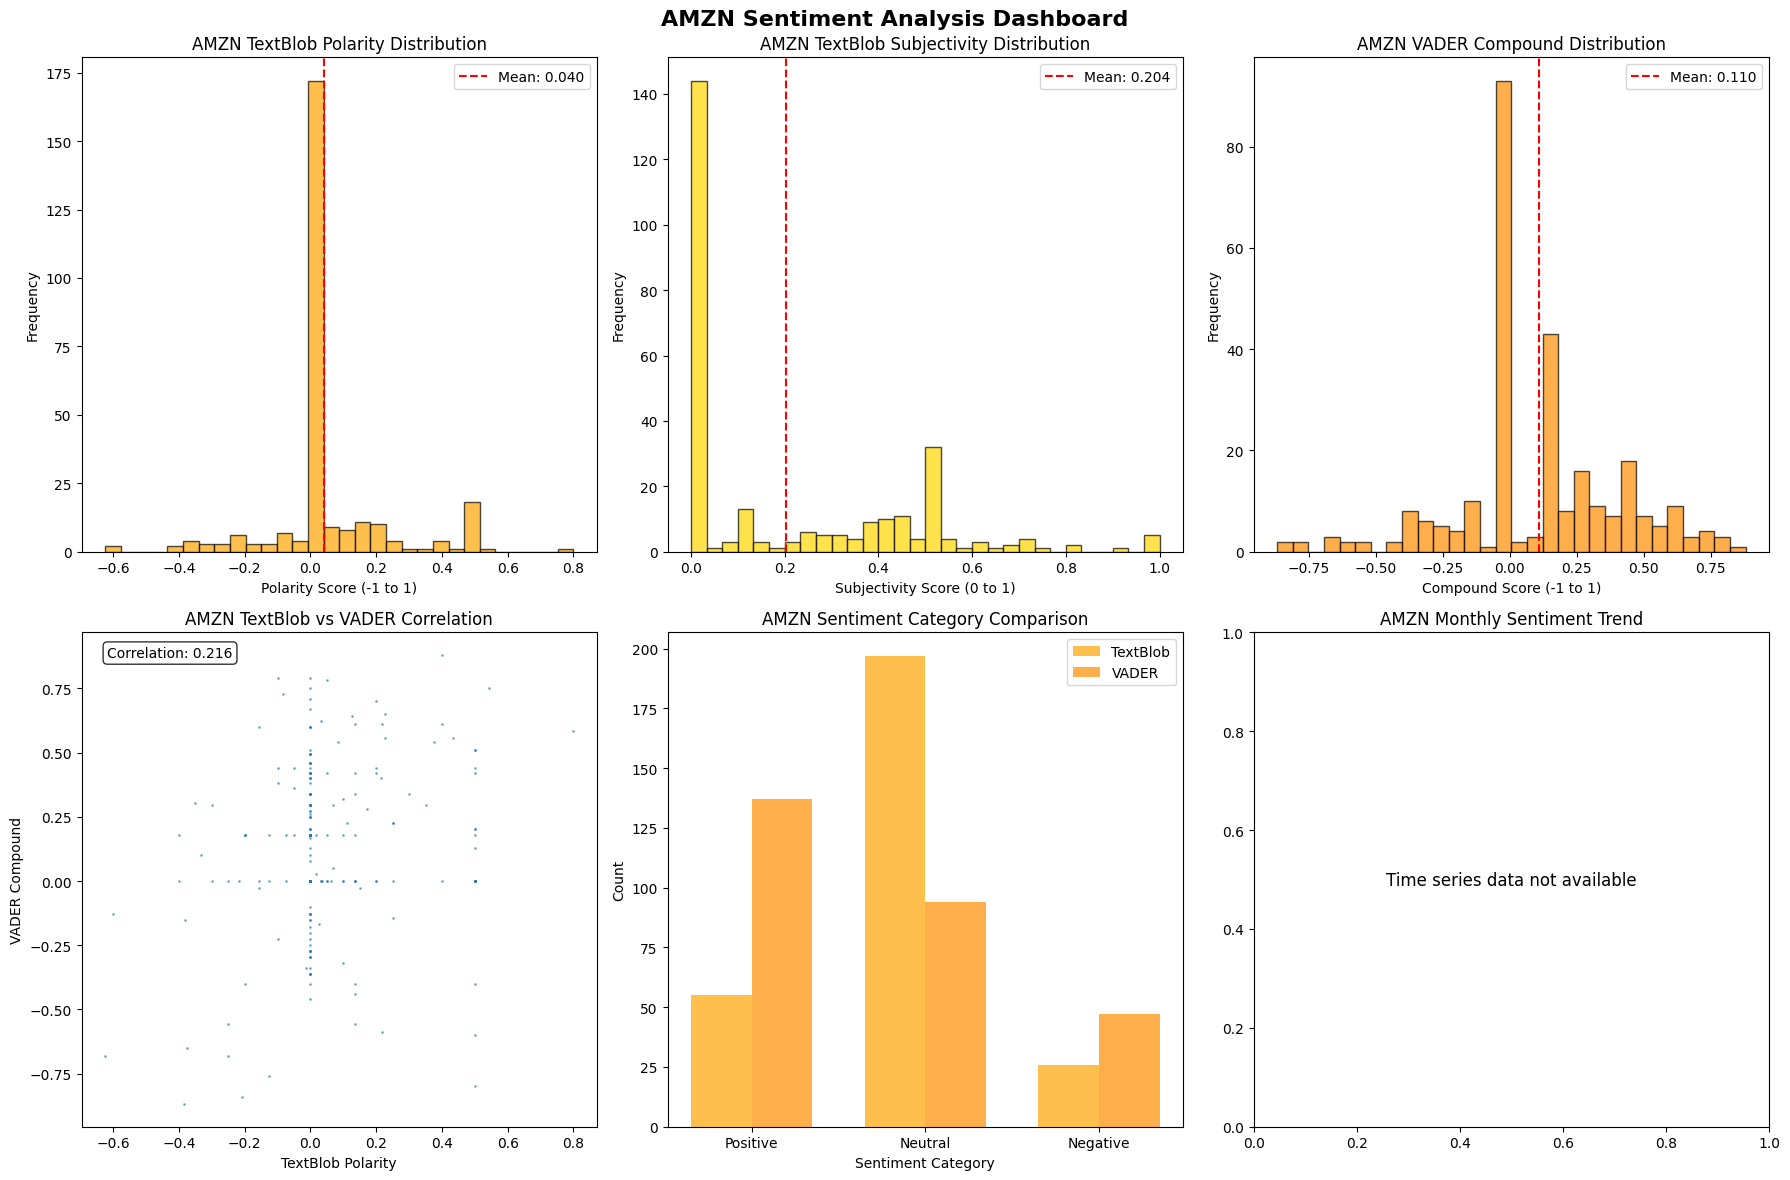

In [6]:
# Create AMZN sentiment visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('AMZN Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# TextBlob Polarity distribution
axes[0, 0].hist(amzn_data['textblob_polarity'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0, 0].set_title('AMZN TextBlob Polarity Distribution')
axes[0, 0].set_xlabel('Polarity Score (-1 to 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(amzn_data['textblob_polarity'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {amzn_data["textblob_polarity"].mean():.3f}')
axes[0, 0].legend()

# TextBlob Subjectivity distribution
axes[0, 1].hist(amzn_data['textblob_subjectivity'], bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[0, 1].set_title('AMZN TextBlob Subjectivity Distribution')
axes[0, 1].set_xlabel('Subjectivity Score (0 to 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(amzn_data['textblob_subjectivity'].mean(), color='red', linestyle='--',
                   label=f'Mean: {amzn_data["textblob_subjectivity"].mean():.3f}')
axes[0, 1].legend()

# VADER Compound distribution
axes[0, 2].hist(amzn_data['vader_compound'], bins=30, alpha=0.7, color='darkorange', edgecolor='black')
axes[0, 2].set_title('AMZN VADER Compound Distribution')
axes[0, 2].set_xlabel('Compound Score (-1 to 1)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(amzn_data['vader_compound'].mean(), color='red', linestyle='--',
                   label=f'Mean: {amzn_data["vader_compound"].mean():.3f}')
axes[0, 2].legend()

# Correlation scatter plot
axes[1, 0].scatter(amzn_data['textblob_polarity'], amzn_data['vader_compound'], alpha=0.5, s=1)
axes[1, 0].set_title('AMZN TextBlob vs VADER Correlation')
axes[1, 0].set_xlabel('TextBlob Polarity')
axes[1, 0].set_ylabel('VADER Compound')
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Sentiment categories
def categorize_sentiment(score, tool='textblob'):
    if tool == 'textblob':
        if score > 0.1:
            return 'Positive'
        elif score < -0.1:
            return 'Negative'
        else:
            return 'Neutral'
    else:  # VADER
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

amzn_data['textblob_category'] = amzn_data['textblob_polarity'].apply(lambda x: categorize_sentiment(x, 'textblob'))
amzn_data['vader_category'] = amzn_data['vader_compound'].apply(lambda x: categorize_sentiment(x, 'vader'))

# Category comparison
categories = ['Positive', 'Neutral', 'Negative']
tb_counts = [amzn_data['textblob_category'].value_counts().get(cat, 0) for cat in categories]
vader_counts = [amzn_data['vader_category'].value_counts().get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, tb_counts, width, label='TextBlob', color='orange', alpha=0.7)
axes[1, 1].bar(x + width/2, vader_counts, width, label='VADER', color='darkorange', alpha=0.7)
axes[1, 1].set_title('AMZN Sentiment Category Comparison')
axes[1, 1].set_xlabel('Sentiment Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend()

# Time series of sentiment (if dates are available)
try:
    amzn_data['date_clean'] = pd.to_datetime(amzn_data['date'], errors='coerce')
    amzn_time = amzn_data.dropna(subset=['date_clean']).copy()
    amzn_time = amzn_time.sort_values('date_clean')
    
    # Resample by month for smoother trend
    amzn_time.set_index('date_clean', inplace=True)
    monthly_sentiment = amzn_time['textblob_polarity'].resample('M').mean()
    
    axes[1, 2].plot(monthly_sentiment.index, monthly_sentiment.values, marker='o', linewidth=2, color='orange')
    axes[1, 2].set_title('AMZN Monthly Sentiment Trend')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Average Polarity')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3)
except:
    axes[1, 2].text(0.5, 0.5, 'Time series data not available', ha='center', va='center',
                   transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('AMZN Monthly Sentiment Trend')

plt.tight_layout()
plt.show()

In [7]:
# Show extreme sentiment examples for AMZN
print("=== AMZN EXTREME SENTIMENT EXAMPLES ===")

# Most positive headlines (TextBlob)
most_positive_tb = amzn_data.nlargest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Positive AMZN Headlines (TextBlob):")
for idx, row in most_positive_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (TextBlob)
most_negative_tb = amzn_data.nsmallest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Negative AMZN Headlines (TextBlob):")
for idx, row in most_negative_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most positive headlines (VADER)
most_positive_vader = amzn_data.nlargest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Positive AMZN Headlines (VADER):")
for idx, row in most_positive_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (VADER)
most_negative_vader = amzn_data.nsmallest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Negative AMZN Headlines (VADER):")
for idx, row in most_negative_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

=== AMZN EXTREME SENTIMENT EXAMPLES ===

Most Positive AMZN Headlines (TextBlob):
   0.800: 'Jeff Bezos and Elon Musk win contracts for spacecraft to land NASA astronauts o...
   0.544: Quick Retreat: Impressive Thursday Turnaround Halted in Its Tracks Amid Fresh Tr...
   0.500: Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BAC, NIO, SO...
   0.500: Pepper Spray, Books On Racism, 'I Can't Breathe' Merchandise Are Top Sellers On ...
   0.500: Apple CEO Writes To Employees About George Floyd Death, Urges For 'Better, More ...

Most Negative AMZN Headlines (TextBlob):
   -0.625: Trump Gets Mad Over Fact Check Warning On Twitter, Claims Election Interference...
   -0.600: Disappointment From Amazon, Apple Weighs On Market As Investors Also Consider En...
   -0.400: The Secret to Tech's Resilience to COVID-19- Infrastructure Expansion...
   -0.400: Amazon Issues Press Release Highlighting 'Crucible,' Its Free-To-Play Shooter Ga...
   -0.383: Gun, Security Stocks Trade 

In [8]:
# Save AMZN results
print("=== SAVING AMZN RESULTS ===")

# Create output dataframe
amzn_output = amzn_data[['headline', 'publisher', 'date', 'stock', 
                       'textblob_polarity', 'textblob_subjectivity', 'textblob_category',
                       'vader_compound', 'vader_positive', 'vader_negative', 'vader_category']].copy()

# Save to CSV
output_file = '../../../data/sentiment_analysis_AMZN.csv'
amzn_output.to_csv(output_file, index=False)
print(f"AMZN results saved to: {output_file}")
print(f"Total AMZN headlines processed: {len(amzn_output)}")

# Display final summary
print("\n=== AMZN FINAL SUMMARY ===")
print(f"Dataset: {len(amzn_data):,} AMZN headlines")
print(f"Date range: {pd.to_datetime(amzn_data['date'], errors='coerce').min()} to {pd.to_datetime(amzn_data['date'], errors='coerce').max()}")
print(f"Unique publishers: {amzn_data['publisher'].nunique()}")
print(f"TextBlob - Mean polarity: {amzn_data['textblob_polarity'].mean():.4f}")
print(f"VADER - Mean compound: {amzn_data['vader_compound'].mean():.4f}")

agreement = (amzn_data['textblob_category'] == amzn_data['vader_category']).mean()
print(f"Tool agreement: {agreement:.2%}")

print("\n=== AMZN SENTIMENT CATEGORY DISTRIBUTIONS ===")
print("\nTextBlob Categories:")
print(amzn_data['textblob_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nVADER Categories:")
print(amzn_data['vader_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== SAVING AMZN RESULTS ===
AMZN results saved to: ../../../data/sentiment_analysis_AMZN.csv
Total AMZN headlines processed: 278

=== AMZN FINAL SUMMARY ===
Dataset: 278 AMZN headlines
Date range: 2020-06-09 11:36:51-04:00 to 2020-06-10 13:18:50-04:00
Unique publishers: 36
TextBlob - Mean polarity: 0.0403
VADER - Mean compound: 0.1097
Tool agreement: 41.01%

=== AMZN SENTIMENT CATEGORY DISTRIBUTIONS ===

TextBlob Categories:
textblob_category
Neutral     70.86%
Positive    19.78%
Negative     9.35%
Name: proportion, dtype: str

VADER Categories:
vader_category
Positive    49.28%
Neutral     33.81%
Negative    16.91%
Name: proportion, dtype: str


## AMZN Sentiment Analysis Summary

### Key Findings:
- **Overall Sentiment**: [Based on mean polarity/compound scores]
- **Sentiment Distribution**: [Analysis of positive/negative/neutral breakdown]
- **Subjectivity Level**: [Analysis of how objective vs subjective AMZN news is]
- **Tool Agreement**: [How well TextBlob and VADER agree on AMZN sentiment]

### Insights:
- AMZN is e-commerce and cloud computing leader, sentiment reflects retail and tech sector health
- High news volume indicates strong investor interest in e-commerce trends
- Sentiment patterns may correlate with AWS performance, Prime growth, and retail competition

### Recommendations:
- Monitor AMZN sentiment as an e-commerce and cloud computing indicator
- Use sentiment trends to anticipate retail seasonality impacts and AWS growth
- Compare AMZN sentiment with other tech giants for relative strength analysis